# Hyperparameter Tuning — Results Visualization

**Pipeline**: All tuning computation (Two-Stage + Optuna) is pre-computed via
`python -m logistics_delay.run_tuning` and cached as CSV files.
This notebook loads the cached results for display and comparison.

**Models**: LogisticRegression, DecisionTree, RandomForest, XGBoost, LightGBM, CatBoost

In [1]:
import sys
from pathlib import Path

PROJ = Path.cwd().parent
sys.path.insert(0, str(PROJ / "src"))

import matplotlib.pyplot as plt
import pandas as pd

from logistics_delay.utils.paths import TABLES_DIR, ensure_output_dirs

import warnings
warnings.filterwarnings("ignore")

# ── Publication style ──────────────────────────
PALETTE = {
    "blue_main": "#0F4D92", "blue_secondary": "#3775BA",
    "green_1": "#DDF3DE", "green_2": "#AADCA9", "green_3": "#8BCF8B",
    "red_1": "#F6CFCB", "red_2": "#E9A6A1", "red_strong": "#B64342",
    "neutral": "#CFCECE", "highlight": "#FFD700",
    "teal": "#42949E", "violet": "#9A4D8E",
}

plt.rcParams.update({
    "font.family": ["Arial", "Microsoft YaHei", "DejaVu Sans", "sans-serif"],
    "font.size": 15,
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.linewidth": 2.5,
    "legend.frameon": False,
    "svg.fonttype": "none",
})
plt.rcParams['axes.unicode_minus'] = False
ensure_output_dirs()

print('[OK] Imports complete')

[OK] Imports complete


In [2]:
# Data loading — for reference only; tuning results are loaded from cached CSVs below
import pandas as pd
from logistics_delay.data.loader import load_processed
df = load_processed()
print(f"Data: {df.shape}, delay rate: {df['Answer'].mean() * 100:.2f}%")

[loader] Preprocessed data loaded: (6854, 54)
[loader] Delay rate: 63.19%
Data: (6854, 54), delay rate: 63.19%


In [3]:
# Temporal split info — for reference only
from logistics_delay.models.train import temporal_split
from logistics_delay.models.tuning import compute_and_print_spw
X_train_enc, X_test_enc, y_train, y_test, spw_t, cutoff = temporal_split(df, "enc")
spw_t, spw_candidates = compute_and_print_spw(y_train)

[train] Temporal split: cutoff 2020-08-08
[train] Train: 5483 records, 2019-03-18 ~ 2020-08-08
[train] Test: 1371 records, 2020-08-08 ~ 2020-12-03
[train] scale_pos_weight = 0.3818
  Sample distribution and scale_pos_weight computation

Training set sample distribution:
  Total: 5483
  Positive (delayed): 3968 (72.37%)
  Negative (on-time): 1515 (27.63%)
  spw_t (neg/pos) = 0.3818

TimeSeriesSplit(5 folds) per-fold delay rate:
  Fold   Train delay    Val delay      Val pos rate
  ------------------------------------------------------
  Fold 0   0.87        %  87.95       %  87.95%
  Fold 1   44.29       %  98.69       %  98.69%
  Fold 2   62.39       %  98.58       %  98.58%
  Fold 3   71.42       %  79.08       %  79.08%
  Fold 4   72.95       %  69.44       %  69.44%

Dynamically generated scale_pos_weight candidates:
  0.1909, 0.2864, 0.3818, 0.4773, 0.5727
  Rule: [spw_t×0.5, spw_t×0.75, spw_t×1.0, spw_t×1.25, spw_t×1.5]


In [4]:
# Load pre-computed tuning results from run_tuning.py
results_stage2 = pd.read_csv(TABLES_DIR / "tuning_results.csv")
results_optuna = pd.read_csv(TABLES_DIR / "optuna_tuning_results.csv")

print(f"Two-stage results: {len(results_stage2)} models")
print(f"Optuna results:    {len(results_optuna)} models")
print()
print("Two-stage models:", results_stage2["model"].tolist())
print("Optuna models:   ", results_optuna["model"].tolist())

Two-stage results: 6 models
Optuna results:    6 models

Two-stage models: ['LogisticRegression', 'DecisionTreeClassifier', 'RandomForestClassifier', 'XGBClassifier', 'LGBMClassifier', 'CatBoostClassifier']
Optuna models:    ['LogisticRegression', 'DecisionTreeClassifier', 'RandomForestClassifier', 'XGBClassifier', 'CatBoostClassifier', 'LGBMClassifier']


In [5]:
# ── Combined comparison table ──
print("=" * 110)
print("  Two-Stage vs Optuna — CV AUC comparison (all 6 models)")
print("=" * 110)

header = f"{'Model':<28s} {'Two-Stage CV AUC':>18s} {'Optuna CV AUC':>18s} {'ΔCV AUC':>10s}"
print(header)
print("-" * 110)

optuna_dict = {row["model"]: row for _, row in results_optuna.iterrows()}
for _, row2 in results_stage2.iterrows():
    m2 = row2["model"]
    row_o = optuna_dict.get(m2)
    cv2 = row2["cv_auc"] * 100
    if row_o is not None:
        cvo = row_o["cv_auc"] * 100
        delta = cvo - cv2
        delta_str = f"+{delta:.2f}%" if delta >= 0 else f"{delta:.2f}%"
    else:
        cvo = float("nan")
        delta_str = "N/A"
    print(f"{m2:<28s} {cv2:>16.2f}% {cvo:>16.2f}% {delta_str:>10s}")

print("-" * 110)

# Test AUC comparison
print(f"\n{'=' * 110}")
print("  Two-Stage vs Optuna — Test AUC comparison (all 6 models)")
print("=" * 110)
print(f"{'Model':<28s} {'Two-Stage Test AUC':>18s} {'Optuna Test AUC':>18s} {'ΔTest AUC':>10s}")
print("-" * 110)

for _, row2 in results_stage2.iterrows():
    m2 = row2["model"]
    row_o = optuna_dict.get(m2)
    t2 = row2["test_auc"] * 100
    if row_o is not None:
        to = row_o["test_auc"] * 100
        delta = to - t2
        delta_str = f"+{delta:.2f}%" if delta >= 0 else f"{delta:.2f}%"
    else:
        to = float("nan")
        delta_str = "N/A"
    print(f"{m2:<28s} {t2:>16.2f}% {to:>16.2f}% {delta_str:>10s}")

print("-" * 110)

# ── Full summary table ──
print(f"\n{'=' * 60}")
print("  Full results summary")
print("=" * 60)

results_stage2["method"] = "two-stage"
results_optuna["method"] = "optuna"
results_all = pd.concat([results_stage2, results_optuna], ignore_index=True)

summary = results_all[["method", "model", "cv_auc", "test_auc", "test_f1"]].copy()
summary["cv_auc"] = summary["cv_auc"] * 100
summary["test_auc"] = summary["test_auc"] * 100
summary.columns = ["Method", "Model", "CV AUC(%)", "Test AUC(%)", "Test F1"]
print(summary.to_string(index=False))

  Two-Stage vs Optuna — CV AUC comparison (all 6 models)
Model                          Two-Stage CV AUC      Optuna CV AUC    ΔCV AUC
--------------------------------------------------------------------------------------------------------------
LogisticRegression                      60.33%            60.68%     +0.34%
DecisionTreeClassifier                  63.15%            63.02%     -0.14%
RandomForestClassifier                  65.99%            64.03%     -1.95%
XGBClassifier                           69.23%            68.13%     -1.10%
LGBMClassifier                          61.80%            71.81%    +10.01%
CatBoostClassifier                      74.38%            73.81%     -0.57%
--------------------------------------------------------------------------------------------------------------

  Two-Stage vs Optuna — Test AUC comparison (all 6 models)
Model                        Two-Stage Test AUC    Optuna Test AUC  ΔTest AUC
-------------------------------------------------

---
## Stage 5 — Best Parameters

In [6]:
print("=" * 60)
print("  Best parameters per model — Two-Stage")
print("=" * 60)
for _, row in results_stage2.iterrows():
    print(f"\n>>> {row['model']}")
    print(f"    CV AUC  = {row['cv_auc'] * 100:.2f}%")
    print(f"    Test AUC = {row['test_auc'] * 100:.2f}%")
    print(f"    Test F1  = {row['test_f1']:.4f}")
    print(f"    best_params: {row['best_params']}")

print(f"\n{'=' * 60}")
print("  Best parameters per model — Optuna")
print("=" * 60)
for _, row in results_optuna.iterrows():
    print(f"\n>>> {row['model']}")
    print(f"    CV AUC  = {row['cv_auc'] * 100:.2f}%")
    print(f"    Test AUC = {row['test_auc'] * 100:.2f}%")
    print(f"    Test F1  = {row['test_f1']:.4f}")
    print(f"    best_params: {row['best_params']}")

  Best parameters per model — Two-Stage

>>> LogisticRegression
    CV AUC  = 60.33%
    Test AUC = 91.63%
    Test F1  = 0.7189
    best_params: C=100, class_weight=balanced, max_iter=1000, penalty=l2, solver=lbfgs

>>> DecisionTreeClassifier
    CV AUC  = 63.15%
    Test AUC = 85.09%
    Test F1  = 0.4048
    best_params: class_weight=None, criterion=entropy, max_depth=4, min_samples_leaf=50, min_samples_split=10

>>> RandomForestClassifier
    CV AUC  = 65.99%
    Test AUC = 82.75%
    Test F1  = 0.6941
    best_params: bootstrap=False, class_weight=balanced, max_depth=15, max_features=sqrt, min_samples_leaf=5, min_samples_split=10, n_estimators=50

>>> XGBClassifier
    CV AUC  = 69.23%
    Test AUC = 84.10%
    Test F1  = 0.6832
    best_params: colsample_bytree=1.0000, gamma=1, learning_rate=0.0100, max_depth=8, min_child_weight=3, n_estimators=300, reg_alpha=1, reg_lambda=0.1000, scale_pos_weight=0.5727, subsample=0.6000

>>> LGBMClassifier
    CV AUC  = 61.80%
    Test AUC = 86

In [7]:
# ═══════════════════════════════════════════════════
#  Load baseline results (saved from 03_modeling.ipynb)
# ═══════════════════════════════════════════════════
NAME_MAP = {"LogisticRegression": "LogisticRegression", "DecisionTree": "DecisionTreeClassifier",
            "RandomForest": "RandomForestClassifier", "XGBoost": "XGBClassifier",
            "CatBoost": "CatBoostClassifier", "LightGBM": "LGBMClassifier"}

baseline = pd.read_csv(TABLES_DIR / "baseline_results.csv")
baseline["model"] = baseline["model"].map(NAME_MAP)
baseline = baseline.rename(columns={"test_auc": "auc", "test_f1": "f1"})

two_stage = pd.read_csv(TABLES_DIR / "tuning_results.csv")[["model", "test_auc", "test_f1"]]
two_stage.columns = ["model", "auc", "f1"]
optuna = pd.read_csv(TABLES_DIR / "optuna_tuning_results.csv")[["model", "test_auc", "test_f1"]]
optuna.columns = ["model", "auc", "f1"]

all_comp = pd.concat([
    baseline.assign(method="Baseline"),
    two_stage.assign(method="Two-Stage"),
    optuna.assign(method="Optuna"),
], ignore_index=True)
print(f"Loaded: {all_comp['model'].nunique()} models x {all_comp['method'].nunique()} methods")
print(all_comp.to_string(index=False))

Loaded: 6 models x 3 methods
                 model      auc       f1    method
    LogisticRegression 0.916523 0.718881  Baseline
DecisionTreeClassifier 0.394563 0.389993  Baseline
RandomForestClassifier 0.741362 0.428458  Baseline
         XGBClassifier 0.616677 0.388970  Baseline
    CatBoostClassifier 0.778890 0.603636  Baseline
        LGBMClassifier 0.686082 0.407625  Baseline
    LogisticRegression 0.916277 0.718881 Two-Stage
DecisionTreeClassifier 0.850895 0.404776 Two-Stage
RandomForestClassifier 0.827524 0.694132 Two-Stage
         XGBClassifier 0.840954 0.683246 Two-Stage
        LGBMClassifier 0.863523 0.651357 Two-Stage
    CatBoostClassifier 0.894288 0.763906 Two-Stage
    LogisticRegression 0.917335 0.717468    Optuna
DecisionTreeClassifier 0.770078 0.721569    Optuna
RandomForestClassifier 0.914896 0.742424    Optuna
         XGBClassifier 0.881028 0.418794    Optuna
    CatBoostClassifier 0.907694 0.442945    Optuna
        LGBMClassifier 0.843109 0.419411    Optuna


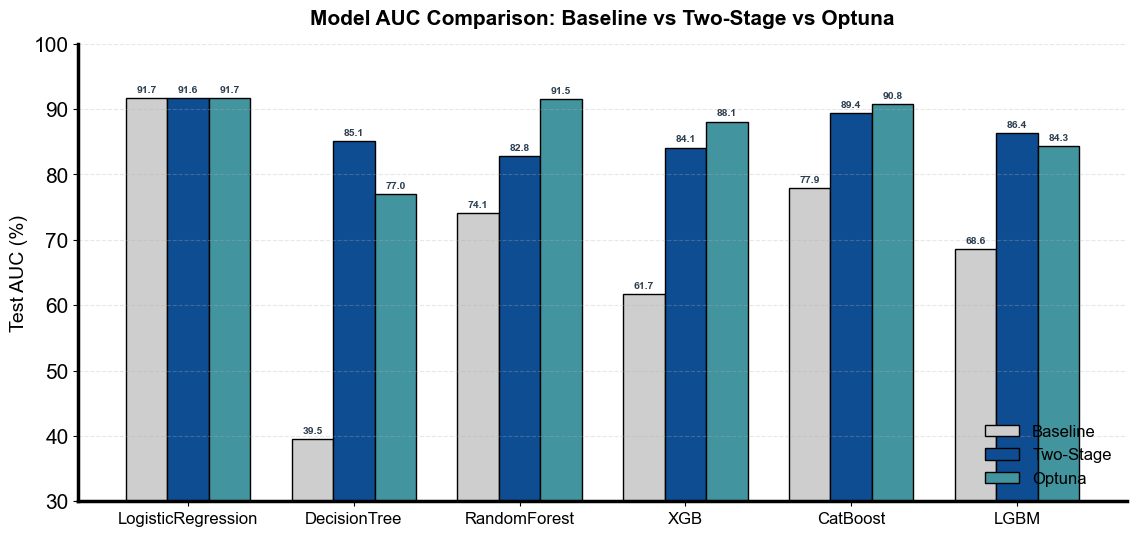

[OK] Saved -> C:\Users\a\Desktop\TU-Eindhoven\Logistics_Delay_Project\outputs\figures\models\auc_comparison_default_vs_tuned.png


In [8]:
# ═══════════════════════════════════════════════════
#  Figure: Test AUC comparison — Baseline vs Two-Stage vs Optuna
# ═══════════════════════════════════════════════════
from logistics_delay.utils.paths import FIGURES_MODELS
import numpy as np

models_order = list(all_comp["model"].unique())
methods = ["Baseline", "Two-Stage", "Optuna"]
method_colors = [PALETTE["neutral"], PALETTE["blue_main"], PALETTE["teal"]]
x = np.arange(len(models_order))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

for i, method in enumerate(methods):
    vals = all_comp[all_comp["method"] == method].set_index("model").loc[models_order, "auc"]
    offset = (i - 1) * width
    bars = ax.bar(x + offset, vals.values * 100, width,
                  color=method_colors[i], edgecolor="black", linewidth=1.0,
                  label=method)
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.6,
                f"{v*100:.1f}", ha="center", va="bottom",
                fontsize=7.5, fontweight="bold", color="#2c3e50")

ax.set_xticks(x)
display_names = [m.replace('Classifier', '') for m in models_order]
ax.set_xticklabels(display_names, fontsize=12)
ax.set_ylabel("Test AUC (%)", fontsize=14)
ax.set_title("Model AUC Comparison: Baseline vs Two-Stage vs Optuna",
             fontsize=15, fontweight="bold", pad=14)
ax.legend(fontsize=12, loc="lower right")
ax.set_ylim(30, 100)
ax.set_yticks(range(30, 101, 10))
ax.grid(axis="y", linestyle="--", alpha=0.3)

fig.tight_layout(pad=2)
fig.savefig(FIGURES_MODELS / "auc_comparison_default_vs_tuned.pdf", dpi=300, bbox_inches="tight")
fig.savefig(FIGURES_MODELS / "auc_comparison_default_vs_tuned.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"[OK] Saved -> {FIGURES_MODELS / 'auc_comparison_default_vs_tuned.png'}")

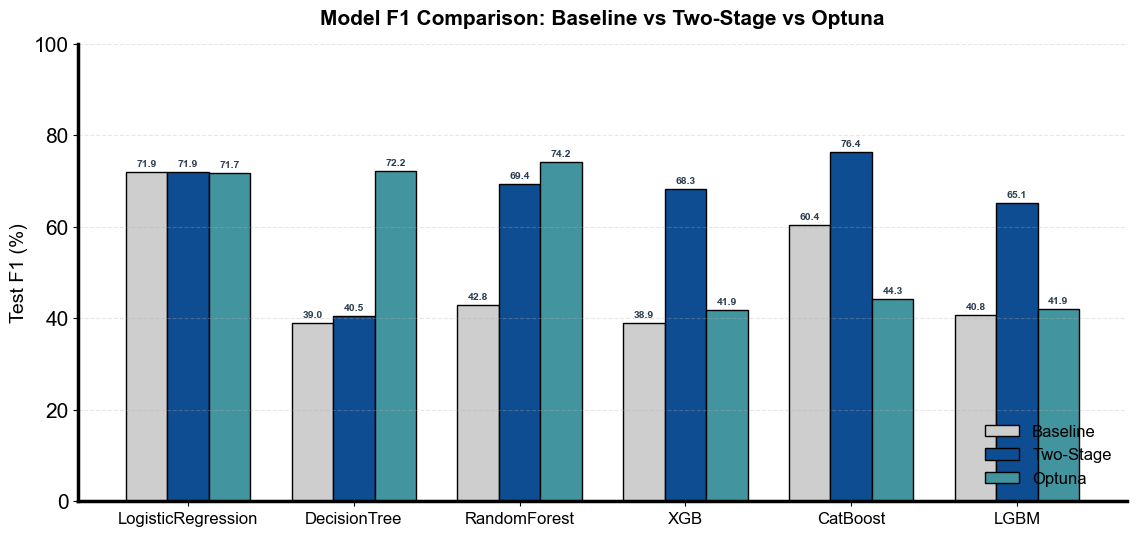

[OK] Saved -> C:\Users\a\Desktop\TU-Eindhoven\Logistics_Delay_Project\outputs\figures\models\f1_comparison_default_vs_tuned.png


In [9]:
# ═══════════════════════════════════════════════════
#  Figure: Test F1 comparison — Baseline vs Two-Stage vs Optuna
# ═══════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 6))

for i, method in enumerate(methods):
    vals = all_comp[all_comp["method"] == method].set_index("model").loc[models_order, "f1"]
    offset = (i - 1) * width
    bars = ax.bar(x + offset, vals.values * 100, width,
                  color=method_colors[i], edgecolor="black", linewidth=1.0,
                  label=method)
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
                f"{v*100:.1f}", ha="center", va="bottom",
                fontsize=7.5, fontweight="bold", color="#2c3e50")

ax.set_xticks(x)
display_names = [m.replace('Classifier', '') for m in models_order]
ax.set_xticklabels(display_names, fontsize=12)
ax.set_ylabel("Test F1 (%)", fontsize=14)
ax.set_title("Model F1 Comparison: Baseline vs Two-Stage vs Optuna",
             fontsize=15, fontweight="bold", pad=14)
ax.legend(fontsize=12, loc="lower right")
ax.set_ylim(0, 100)
ax.grid(axis="y", linestyle="--", alpha=0.3)

fig.tight_layout(pad=2)
fig.savefig(FIGURES_MODELS / "f1_comparison_default_vs_tuned.pdf", dpi=300, bbox_inches="tight")
fig.savefig(FIGURES_MODELS / "f1_comparison_default_vs_tuned.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"[OK] Saved -> {FIGURES_MODELS / 'f1_comparison_default_vs_tuned.png'}")

Loaded: 62 completed / 100 trials  |  Best CV AUC = 71.81%


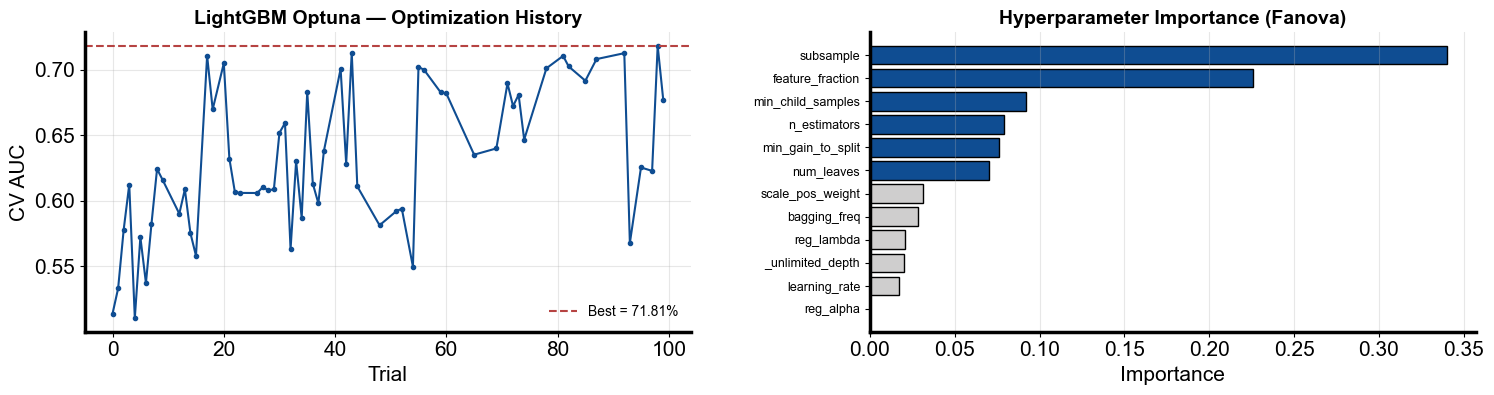

[OK] Saved -> C:\Users\a\Desktop\TU-Eindhoven\Logistics_Delay_Project\outputs\figures\models\lgbm_optuna_history.png


In [10]:
# ═══════════════════════════════════════════════════
#  LightGBM Optuna — optimization history & param importance
# ═══════════════════════════════════════════════════
import pickle
import optuna

study_path = TABLES_DIR / "optuna_studies" / "LGBMClassifier.pkl"
if not study_path.exists():
    print(f"[SKIP] Study not found — run `python -m logistics_delay.run_tuning` first")
else:
    with open(study_path, "rb") as f:
        study = pickle.load(f)

    df_trials = study.trials_dataframe()
    completed = df_trials[df_trials["state"] == "COMPLETE"].copy().sort_values("number")
    print(f"Loaded: {len(completed)} completed / {len(df_trials)} trials  |  "
          f"Best CV AUC = {study.best_value*100:.2f}%")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # ── Optimization history ──
    ax1.plot(completed["number"], completed["value"], "o-",
             color=PALETTE["blue_main"], linewidth=1.5, markersize=3)
    ax1.axhline(study.best_value, color=PALETTE["red_strong"], linestyle="--",
                label=f"Best = {study.best_value*100:.2f}%")
    ax1.set_xlabel("Trial"); ax1.set_ylabel("CV AUC")
    ax1.set_title("LightGBM Optuna — Optimization History", fontsize=14, fontweight="bold")
    ax1.legend(fontsize=10); ax1.grid(alpha=0.3)

    # ── Hyperparameter importance ──
    try:
        importances = optuna.importance.get_param_importances(study)
    except Exception:
        importances = {}

    if importances:
        names = list(importances.keys())
        vals = list(importances.values())
        colors = [PALETTE["blue_main"] if v > 0.05 else PALETTE["neutral"] for v in vals]
        ax2.barh(range(len(names)), vals, color=colors, edgecolor="black", linewidth=1.0)
        ax2.set_yticks(range(len(names)))
        ax2.set_yticklabels(names, fontsize=9)
        ax2.set_xlabel("Importance")
        ax2.set_title("Hyperparameter Importance (Fanova)", fontsize=14, fontweight="bold")
        ax2.grid(axis="x", alpha=0.3)
        ax2.invert_yaxis()
    else:
        ax2.text(0.5, 0.5, "Not available", ha="center", va="center", transform=ax2.transAxes)

    fig.tight_layout(pad=3)
    fig.savefig(FIGURES_MODELS / "lgbm_optuna_history.pdf", dpi=300, bbox_inches="tight")
    fig.savefig(FIGURES_MODELS / "lgbm_optuna_history.png", dpi=300, bbox_inches="tight")
    plt.show()
    print(f"[OK] Saved -> {FIGURES_MODELS / 'lgbm_optuna_history.png'}")
